In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity


In [2]:
df=pd.read_csv("E:/data science/recommendation/anime.csv")
df.head(3)

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262


In [3]:
df.columns = (
    df.columns
    .str.strip()                             
    .str.lower()                             
    .str.replace(r'\s+', ' ', regex=True)     
    .str.replace(' ', '_')                    
)


In [4]:
print(df.shape)
print(df.size)
print(df.isnull().sum().sum())
print(df.duplicated().sum())

(12294, 7)
86058
317
0


In [5]:
df["genre"] = df["genre"].fillna("Unknown")
df["type"] = df["type"].fillna("Unknown")
df["rating"] = df["rating"].fillna(df["rating"].mean())

In [6]:
df["episodes"] = pd.to_numeric(df["episodes"], errors="coerce")
df["episodes"] = df["episodes"].fillna(df["episodes"].median())

In [7]:
print("\nMissing values after cleaning:")
print(df.isnull().sum())



Missing values after cleaning:
anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64


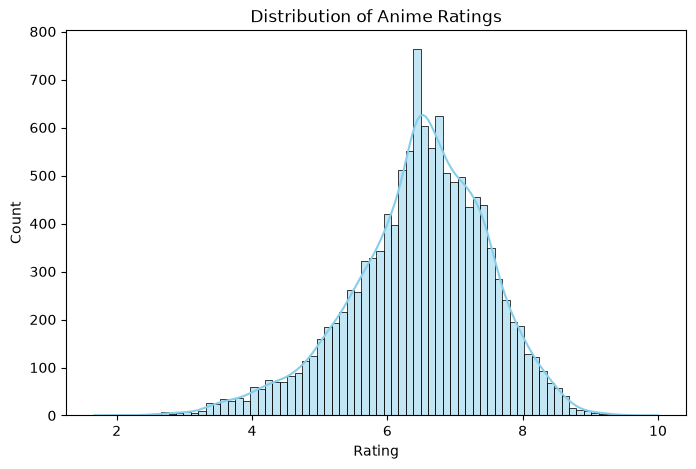

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(df["rating"], kde=True, color="skyblue")
plt.title("Distribution of Anime Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

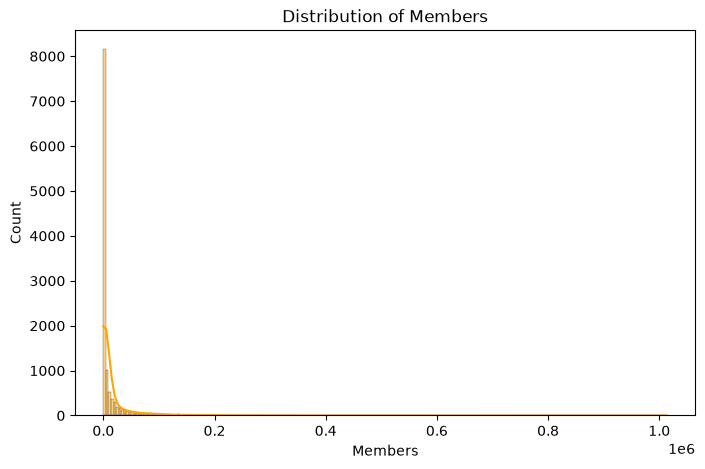

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(df["members"], kde=True, color="orange")
plt.title("Distribution of Members")
plt.xlabel("Members")
plt.ylabel("Count")
plt.show()


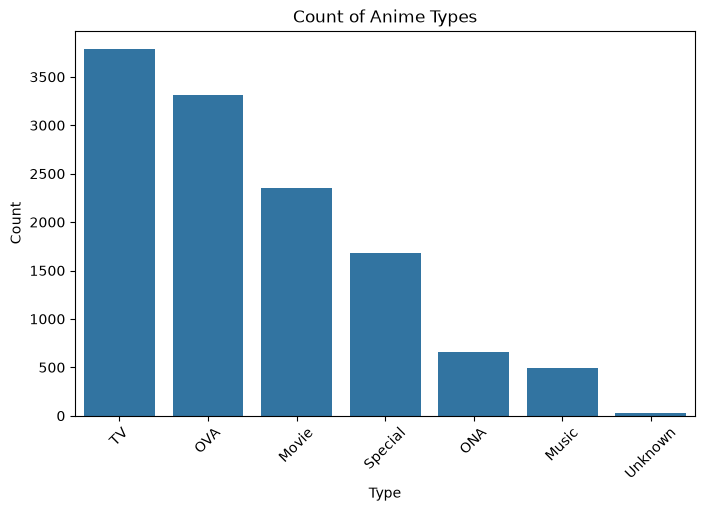

In [10]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="type", order=df["type"].value_counts().index)
plt.title("Count of Anime Types")
plt.xlabel("Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_13584\2247626306.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_rated, x="rating", y="name", palette="viridis")


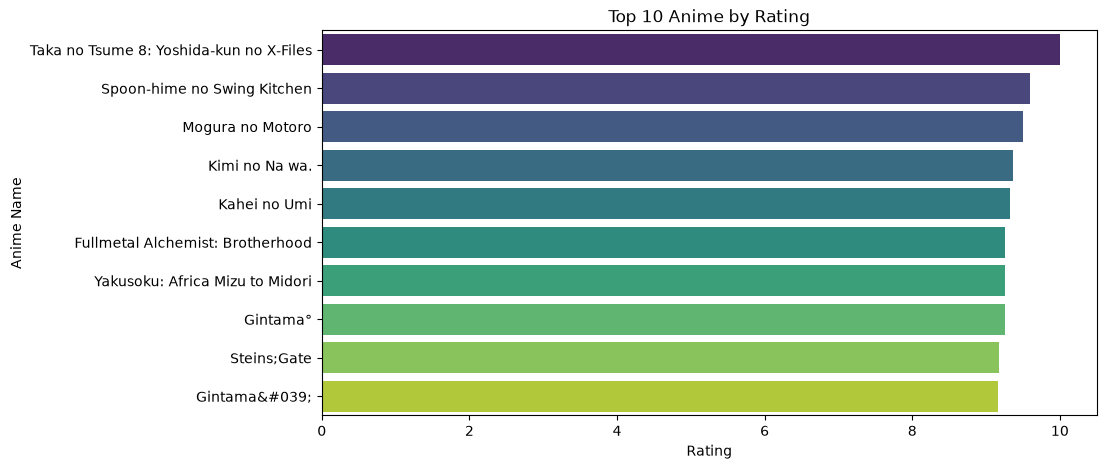

In [11]:
top_rated = df.sort_values(by="rating", ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_rated, x="rating", y="name", palette="viridis")
plt.title("Top 10 Anime by Rating")
plt.xlabel("Rating")
plt.ylabel("Anime Name")
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_13584\3281589572.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_count.values, y=genre_count.index, palette="magma")


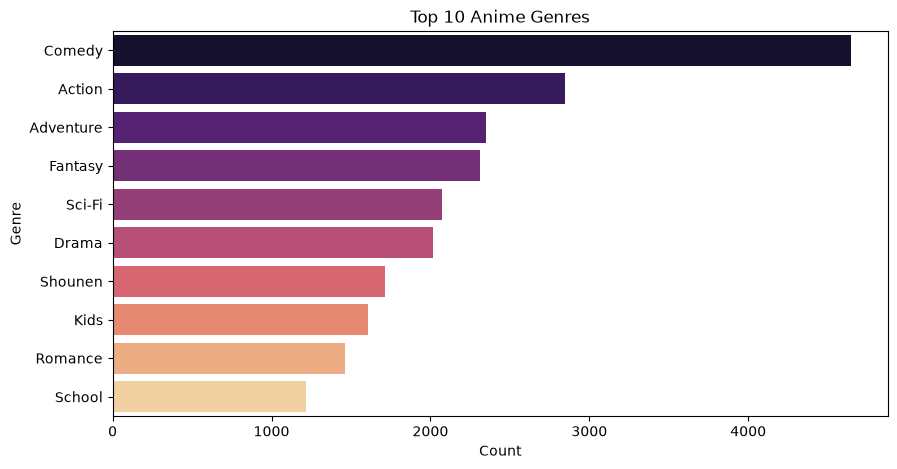

In [12]:
genre_count = df["genre"].str.split(", ").explode().value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=genre_count.values, y=genre_count.index, palette="magma")
plt.title("Top 10 Anime Genres")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()


In [13]:
print("\nSkewness before transformation:")
print(df[["rating", "members", "episodes"]].skew())


Skewness before transformation:
rating      -0.548726
members      6.682934
episodes    23.685908
dtype: float64


In [14]:
df["members_log"] = np.log1p(df["members"])
df["episodes_log"] = np.log1p(df["episodes"])


In [15]:
print("\nSkewness after transformation:")
print(df[["members_log", "episodes_log"]].skew())



Skewness after transformation:
members_log     0.266096
episodes_log    1.053522
dtype: float64


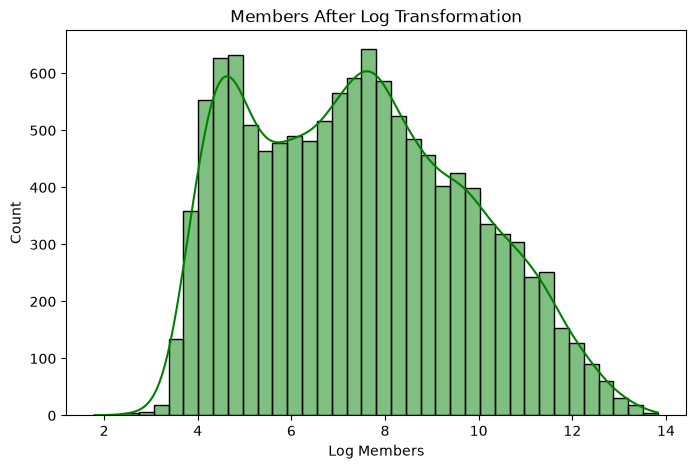

In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(df["members_log"], kde=True, color="green")
plt.title("Members After Log Transformation")
plt.xlabel("Log Members")
plt.ylabel("Count")
plt.show()


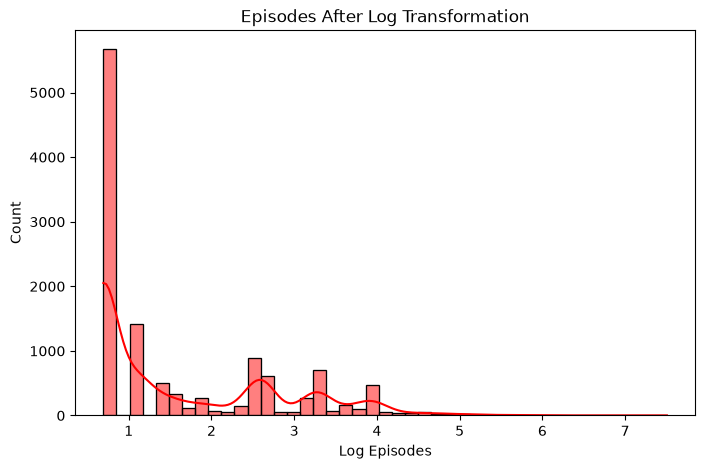

In [17]:
plt.figure(figsize=(8, 5))
sns.histplot(df["episodes_log"], kde=True, color="red")
plt.title("Episodes After Log Transformation")
plt.xlabel("Log Episodes")
plt.ylabel("Count")
plt.show()

In [18]:
df["genre"] = df["genre"].astype(str)

cv = CountVectorizer(stop_words="english")
genre_matrix = cv.fit_transform(df["genre"])

similarity = cosine_similarity(genre_matrix)


In [19]:
def recommend_anime(anime_name):

    if anime_name not in df["name"].values:
        print("Anime not found in dataset")
        return

    index = df[df["name"] == anime_name].index[0]

    distances = list(enumerate(similarity[index]))

    sorted_distances = sorted(distances, reverse=True, key=lambda x: x[1])

    print("\nRecommended Anime for:", anime_name)
    print("--------------------------------")

    for i in sorted_distances[1:11]:
        print(df.iloc[i[0]]["name"])

In [20]:
recommend_anime("Naruto")


Recommended Anime for: Naruto
--------------------------------
Naruto: Shippuuden
Naruto
Boruto: Naruto the Movie - Naruto ga Hokage ni Natta Hi
Naruto x UT
Naruto: Shippuuden Movie 4 - The Lost Tower
Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsugu Mono
Naruto Shippuuden: Sunny Side Battle
Naruto Soyokazeden Movie: Naruto to Mashin to Mitsu no Onegai Dattebayo!!
Kyutai Panic Adventure!
Dragon Ball Z


In [21]:
recommend_anime("Naruto")



Recommended Anime for: Naruto
--------------------------------
Naruto: Shippuuden
Naruto
Boruto: Naruto the Movie - Naruto ga Hokage ni Natta Hi
Naruto x UT
Naruto: Shippuuden Movie 4 - The Lost Tower
Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsugu Mono
Naruto Shippuuden: Sunny Side Battle
Naruto Soyokazeden Movie: Naruto to Mashin to Mitsu no Onegai Dattebayo!!
Kyutai Panic Adventure!
Dragon Ball Z


In [26]:
joblib.dump(cv, "vectorizer.pkl")
joblib.dump(similarity, "similarity.pkl")
joblib.dump(df, "anime_data.pkl")

print("All files saved successfully")

All files saved successfully


Python: 3.12.0 | packaged by Anaconda, Inc. | (main, Oct  2 2023, 17:20:38) [MSC v.1916 64 bit (AMD64)]
Pandas: 3.0.3
